In [11]:
import importlib
import plots
import feature_mining

importlib.reload(plots)
importlib.reload(feature_mining)

import pandas as pd

from plots import *
from feature_mining import *

#### Load labeled dataset

In [12]:
dataframe = pd.read_csv("../data/ait_ads/labeled_combined_ait.csv", low_memory=False)

# make sure timestamps are datetime and sorted
df = dataframe.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

In [13]:
df.columns

Index(['timestamp', 'scenario', 'source', 'category', 'entity', 'raw_log',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'groups_raw',
       'groups_str', 'alert_channel', 'decoder', 'decoder_parent', 'location',
       'mitre_ids', 'mitre_tactic', 'mitre_technique', 'username', 'procname',
       'aminer_component_type', 'aminer_training_mode', 'aminer_new_event',
       'srcip', 'dstip', 'srcport', 'dstport', 'proto', 'is_ids_alert',
       'ids_signature', 'ids_category', 'ids_severity', 'data_json',
       'wazuh_level', 'alert_id', 'event_label', 'y', 'attack_type'],
      dtype='object')

#### Set run name and min_support parameter

In [14]:
run_name="1-itemset-bayes"
output_dir = f"../plots/{run_name}"
os.makedirs(output_dir,exist_ok=True)
min_support=10

#### Normalize `category`

In [15]:
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

### Window based mining run (scenario local)

##### Token mining (transactional)

In [16]:
scorer_name = "split_bayes"
miner_name = "1-itemset"

In [17]:
scenario_rankings, scenario_attack_flags, scenario_memory = window_based_mining(
    df,
    run_name=run_name,
    scorer=split_metric_scorer_bayes(),
    counter=mine_itemset_counts,
    counter_kwargs={"k":1}
)

Running mining for scenario santos....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


santos unique ids df: 88414 unique ids tok: 88414
Running mining for scenario fox....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


fox unique ids df: 24322 unique ids tok: 24322
Running mining for scenario wardbeck....


...

wheeler unique ids df: 139399 unique ids tok: 139399
Running mining for scenario wilson....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


wilson unique ids df: 131971 unique ids tok: 131971
Running mining for scenario harrison....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


harrison unique ids df: 136858 unique ids tok: 136858


#### Heat map for given scenario to show the contrast score of each token over all windows in the scenario

In [18]:
# find min and max global score so we can set a fixed colour scale for all scenario heatmaps
def compute_global_score_limits(scenario_rankings, score_col="combined_score"):
    max_abs = 0.0
    for rankings in scenario_rankings.values():
        for ranking_k in rankings:
            if score_col in ranking_k.columns:
                max_abs = max(max_abs, np.abs(ranking_k[score_col]).max())
    return -max_abs, max_abs

vmin_global, vmax_global = compute_global_score_limits(scenario_rankings)
print(vmin_global, vmax_global)

-10.772571210615583 10.772571210615583


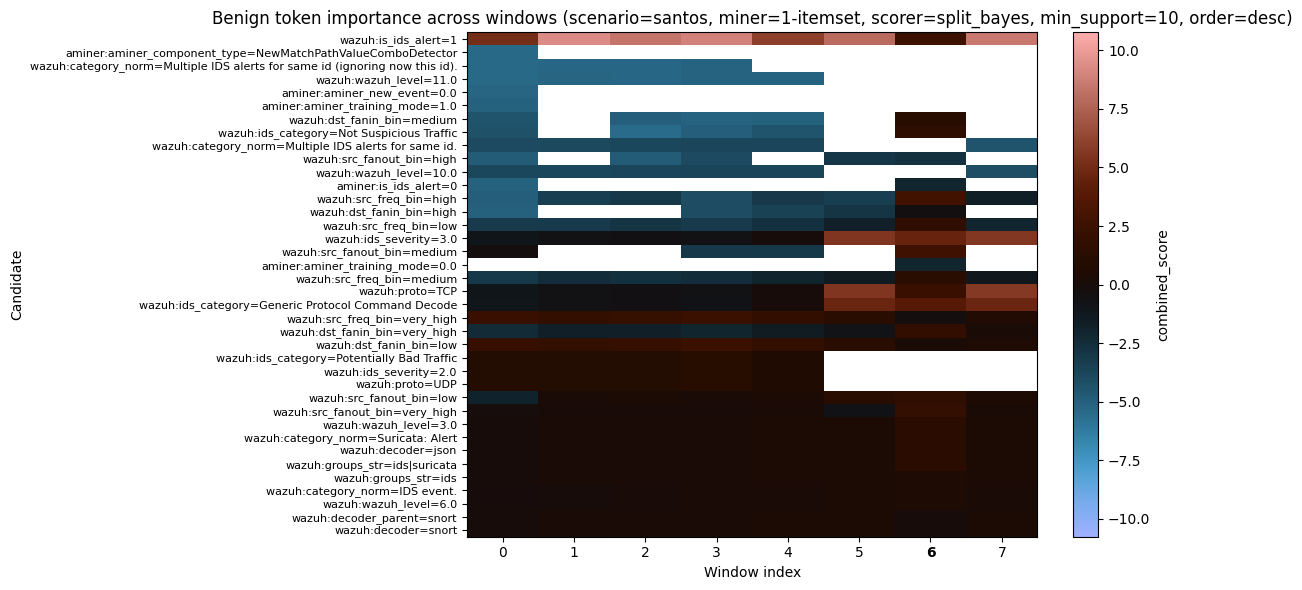

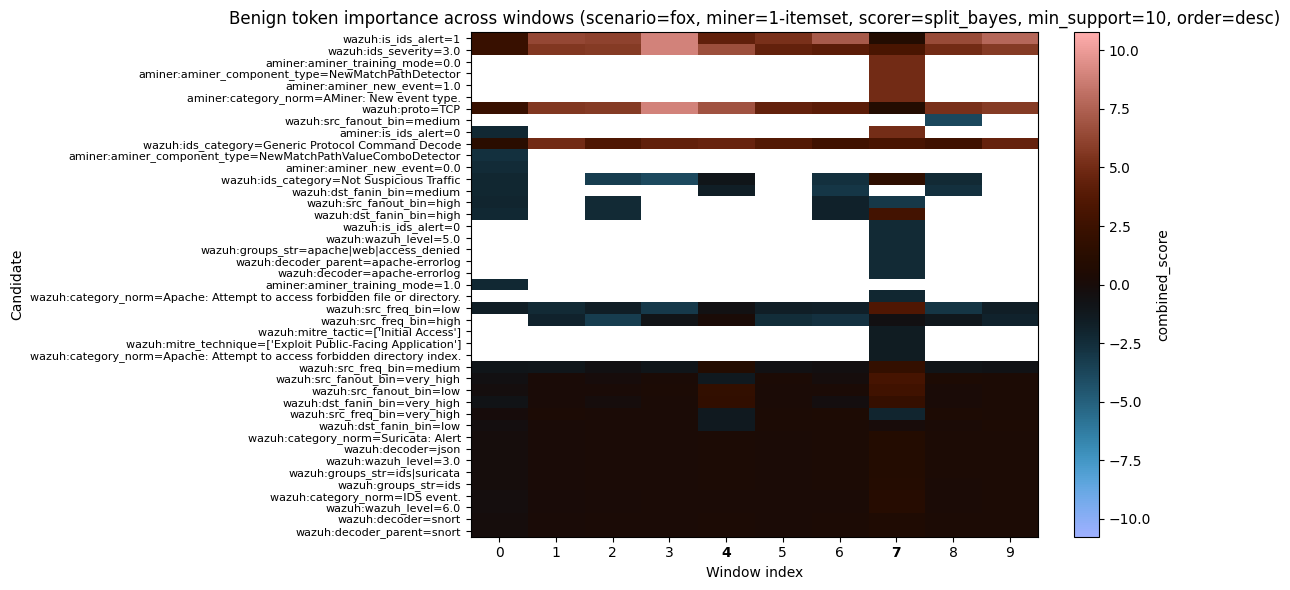

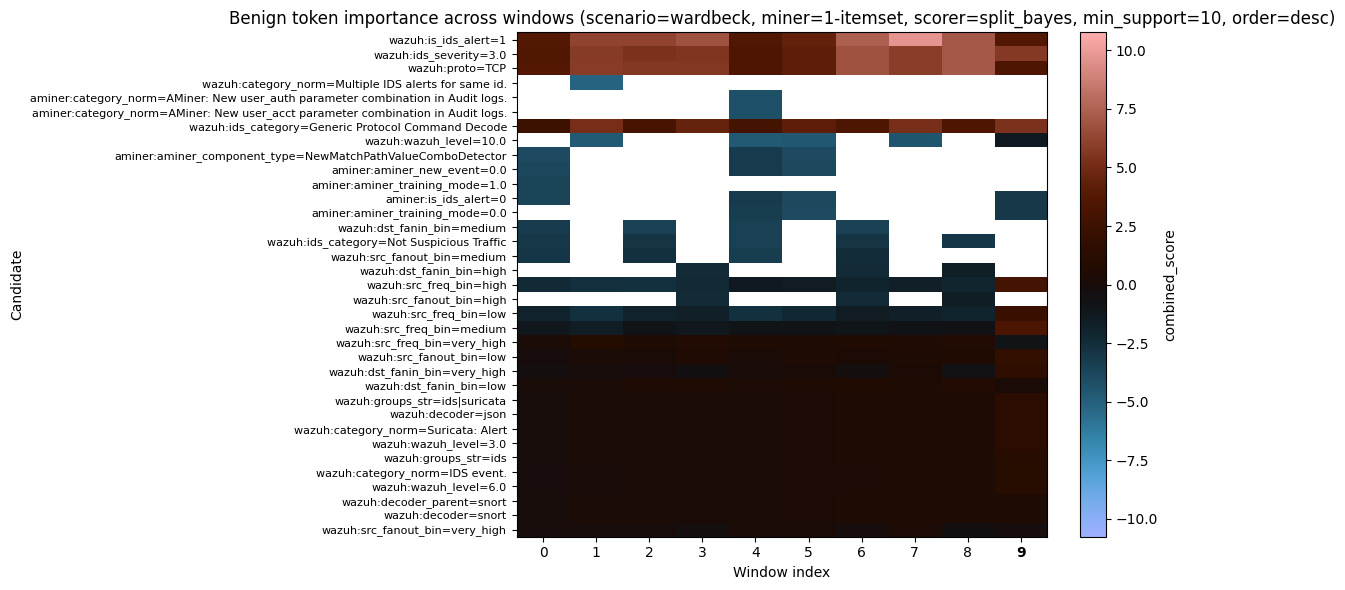

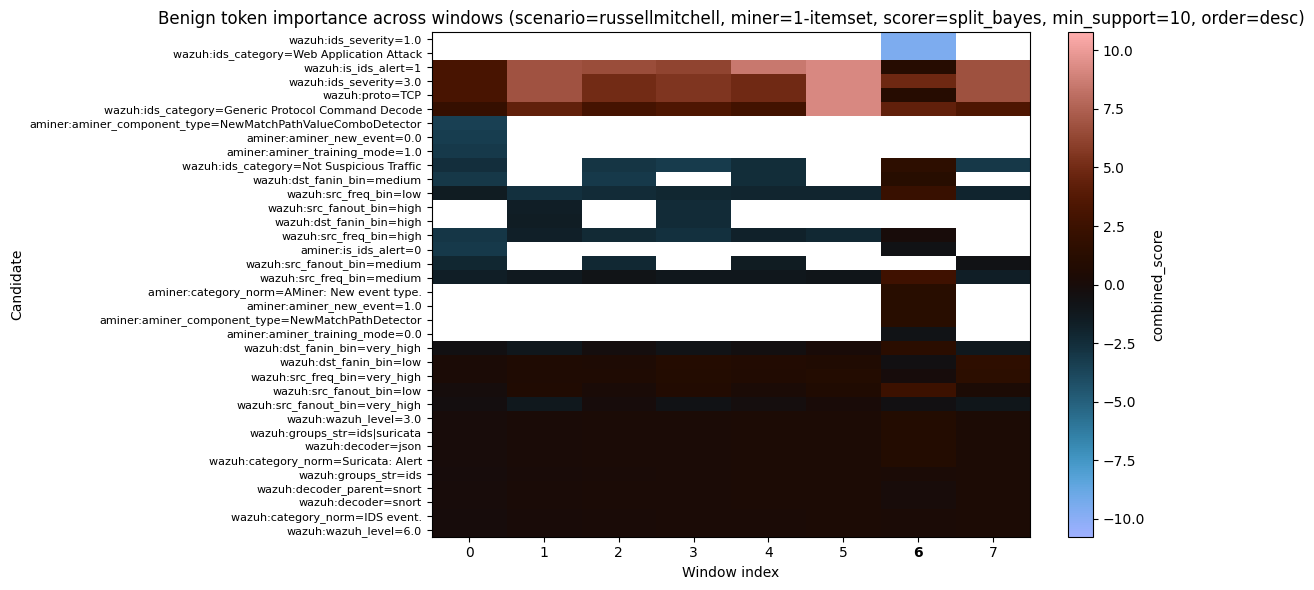

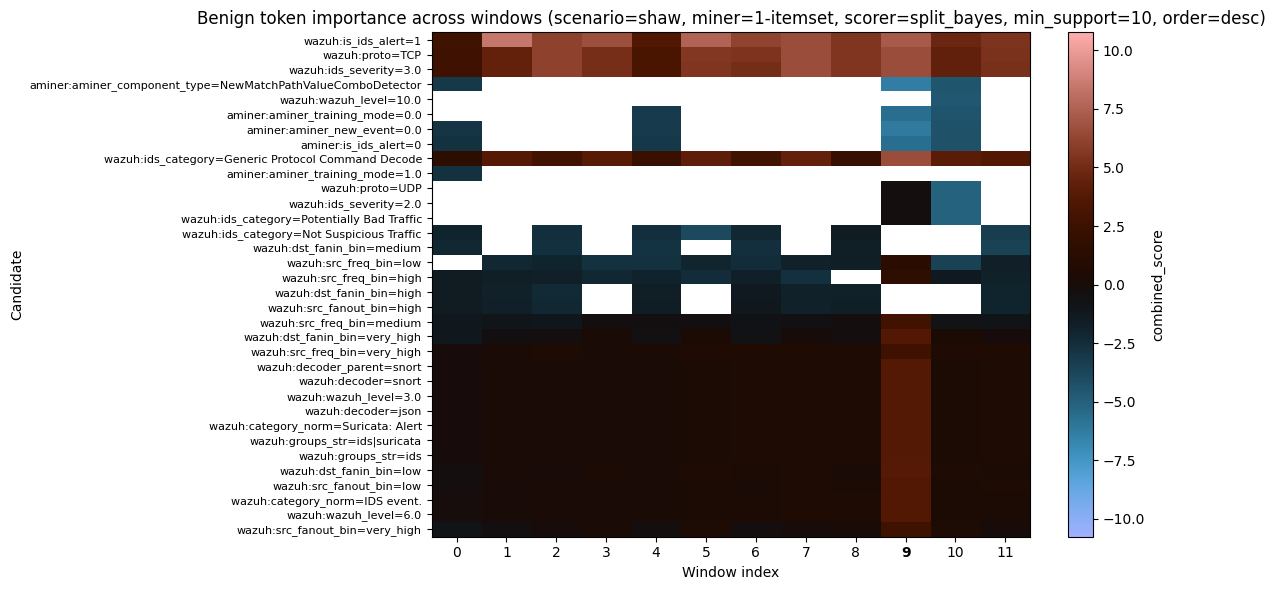

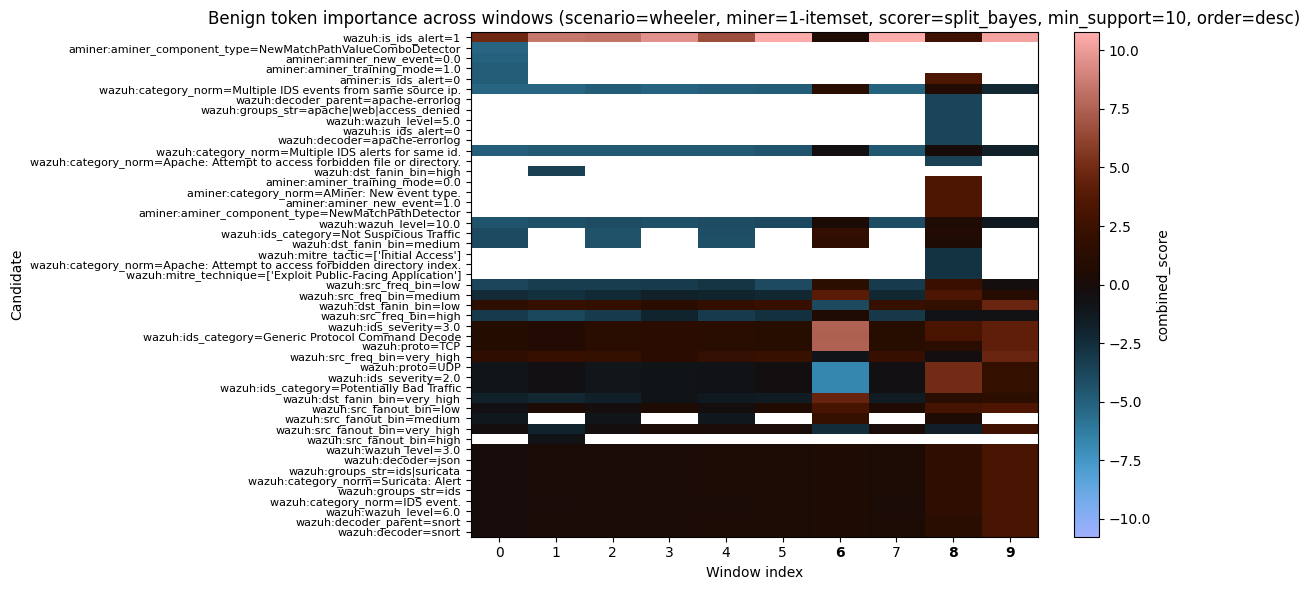

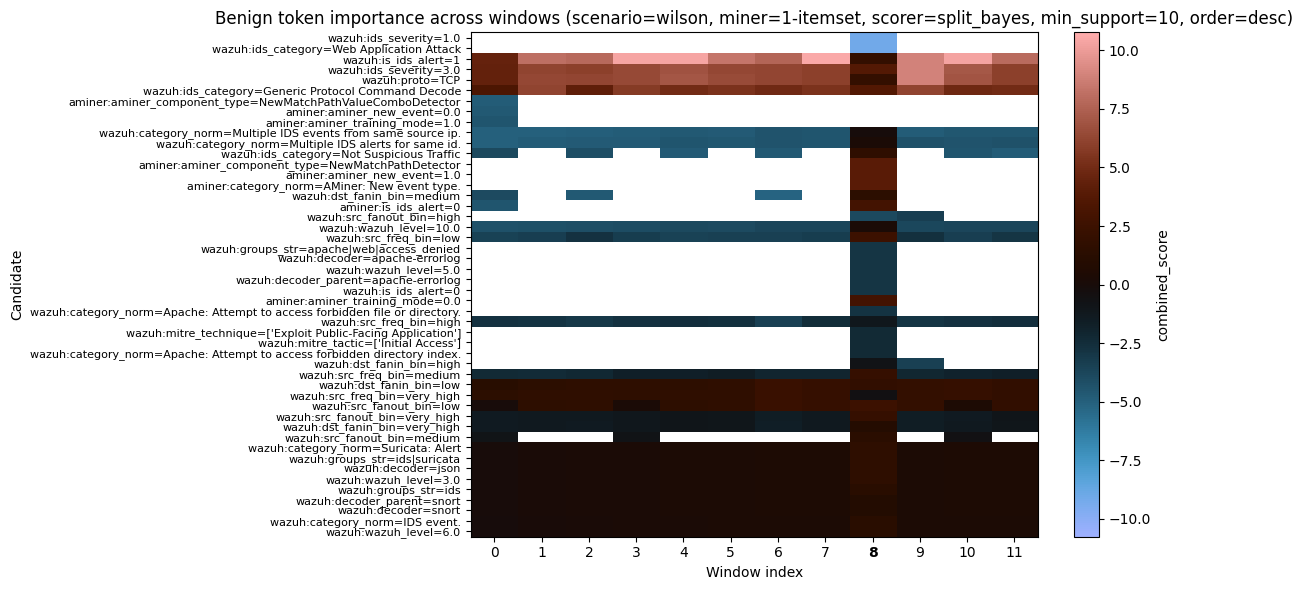

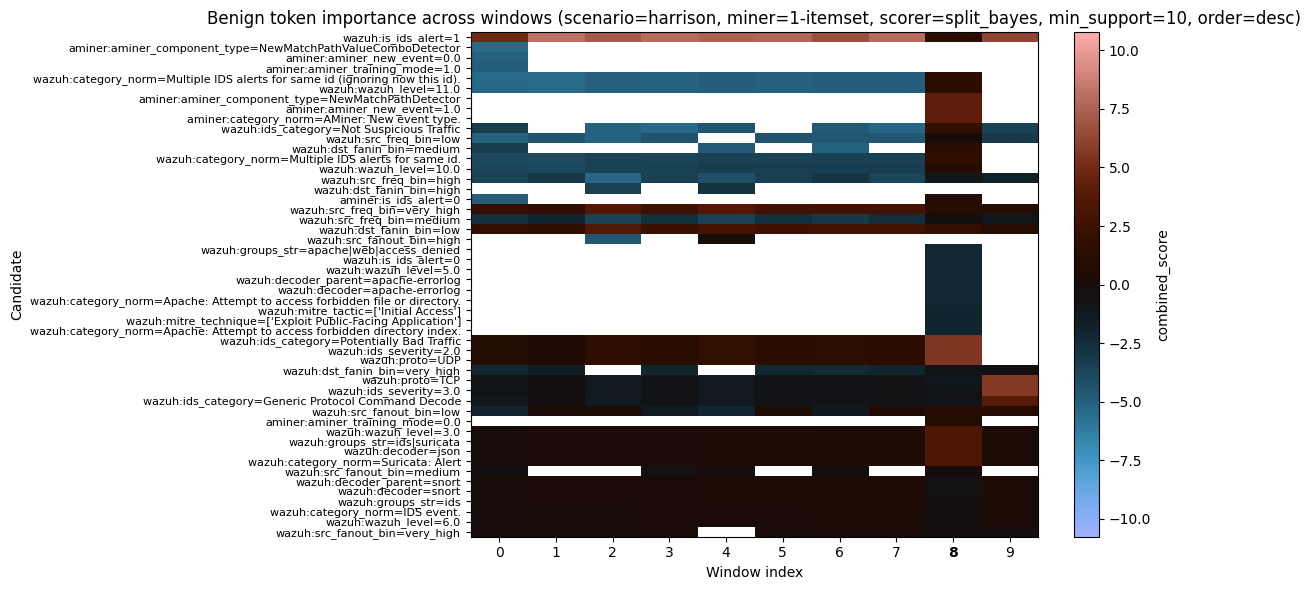

In [19]:
for scenario, df_s in df.groupby("scenario", sort=False):
    rankings = scenario_rankings.get(scenario)
    flags = scenario_attack_flags.get(scenario)
    out_dir = os.path.join(output_dir, "heatmaps")
    os.makedirs(out_dir, exist_ok=True)
    plot_scenario_heatmap(rankings, flags, out_dir, scenario, miner_name, scorer_name, min_support, top_n=50, order="desc", vmin=vmin_global, vmax=vmax_global)

### Save all candidates that are stable and have positive score for each scenario
To be used in ablation study

In [20]:
for scenario, df_s in df.groupby("scenario", sort=False):
    rankings = scenario_rankings.get(scenario)
    find_stable_features(scenario, scenario_rankings, run_name)

Saved stable features for scenario 'santos' to ../out/ait_ads/rankings/1-itemset-bayes/santos_stable_features.csv
Saved stable features for scenario 'fox' to ../out/ait_ads/rankings/1-itemset-bayes/fox_stable_features.csv
Saved stable features for scenario 'wardbeck' to ../out/ait_ads/rankings/1-itemset-bayes/wardbeck_stable_features.csv
Saved stable features for scenario 'russellmitchell' to ../out/ait_ads/rankings/1-itemset-bayes/russellmitchell_stable_features.csv
Saved stable features for scenario 'shaw' to ../out/ait_ads/rankings/1-itemset-bayes/shaw_stable_features.csv
Saved stable features for scenario 'wheeler' to ../out/ait_ads/rankings/1-itemset-bayes/wheeler_stable_features.csv
Saved stable features for scenario 'wilson' to ../out/ait_ads/rankings/1-itemset-bayes/wilson_stable_features.csv
Saved stable features for scenario 'harrison' to ../out/ait_ads/rankings/1-itemset-bayes/harrison_stable_features.csv
